# Demo — Drone Face Recognition (sample inputs and outputs)

Loads the headline `both_phases_original` checkpoint (`best_drone_model_v2.pth`) and runs inference on a curated set of DroneFace images. For each query we show:

- the input image with its metadata parsed from the filename (subject, altitude, distance);
- the model's top-3 predicted identities by cosine similarity to per-identity centroids (leave-one-out, identical to the LOO eval protocol used for Tables 2-6);
- a ✓ / ✗ flag indicating whether the top-1 prediction matches the ground truth.

Sample queries cover: easy training identities, the validation identity (I, never seen during gradient steps), held-out identities (J,K, also never seen), the hardest altitude (5 m), and the hardest distances (2 m close range and 14-16 m far range).

In [1]:
import os, sys
from pathlib import Path

PROJECT_ROOT = Path('/home/buthaina.almulla/Documents/CV7502')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from facenet_pytorch import InceptionResnetV1
from model import Embeddinghead

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

backbone = InceptionResnetV1(pretrained='vggface2').to(device)
head = Embeddinghead(input_dim=512, Embedding_dim=256).to(device)
ckpt = torch.load('checkpoints/checkpoints/best_drone_model_v2.pth', map_location=device, weights_only=False)
backbone.load_state_dict(ckpt['backbone'])
head.load_state_dict(ckpt['head'])
backbone.eval(); head.eval()
print('loaded best_drone_model_v2.pth | epoch', ckpt.get('epoch', '?'), '| in-training val_R1 =', round(ckpt.get('val_rank1', float('nan')), 2), '%')

TRAIN_IDS = list('ABCDEFGH'); VAL_IDS = ['I']; HELDOUT_IDS = ['J','K']
ALL_IDS = TRAIN_IDS + VAL_IDS + HELDOUT_IDS

/home/buthaina.almulla/Documents/CV7502/venv/lib/python3.10/site-packages/facenet_pytorch/models/inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  st

loaded best_drone_model_v2.pth | epoch 18 | in-training val_R1 = 72.58 %


## Build the gallery

We embed every DroneFace image (1,364 across 11 identities) once. At query time we compute leave-one-out centroids: the centroid for the query's identity is the L2-normalized mean of all *other* same-identity embeddings, while centroids for other identities are means of all their images. This matches the LOO protocol used to compute Tables 2-6.

In [2]:
SPLIT = PROJECT_ROOT / 'datasets/droneface/split'
eval_t = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

items = []  # (path, identity)
for sp, ids in [('train', TRAIN_IDS), ('validation', VAL_IDS), ('test', HELDOUT_IDS)]:
    for ident in ids:
        folder = SPLIT / sp / ident
        for fn in sorted(os.listdir(folder)):
            if fn.lower().endswith(('.jpg', '.jpeg', '.png')):
                items.append((folder / fn, ident))

@torch.no_grad()
def embed(paths, batch=64):
    out = []
    for s in range(0, len(paths), batch):
        chunk = paths[s:s+batch]
        x = torch.stack([eval_t(Image.open(p).convert('RGB')) for p in chunk]).to(device)
        out.append(head(backbone(x)).cpu())
    return torch.cat(out, dim=0)

all_embs = embed([p for p, _ in items])
all_lbls = np.array([i for _, i in items])
all_paths = [str(p) for p, _ in items]

# Per-identity sums + counts, used to build LOO centroids on demand.
sums = {i: all_embs[all_lbls == i].sum(dim=0) for i in ALL_IDS}
counts = {i: int((all_lbls == i).sum()) for i in ALL_IDS}
print(f'gallery: {len(items)} images across {len(ALL_IDS)} identities')

gallery: 1364 images across 11 identities


## Inference helper

For a query image at index `i` (in the gallery list), build LOO centroids and return the top-K most similar identities by cosine.

In [3]:
HEIGHT_MAP = {'0': 1.5, '3': 3.0, '4': 4.0, '5': 5.0}
MALE = set('abcegjk'); FEMALE = set('dfhi')

def parse_filename(fn):
    base = Path(fn).stem.lower()
    parts = base.split('_')
    if len(parts) < 5: return {}
    h = HEIGHT_MAP.get(parts[2])
    try: d = 17 - int(parts[4]) / 2
    except ValueError: d = None
    g = 'male' if parts[0] in MALE else ('female' if parts[0] in FEMALE else None)
    return {'subject': parts[0].upper(), 'camera': parts[1], 'altitude_m': h, 'distance_m': d, 'gender': g}

def predict(query_idx, k=3):
    """Return [(identity, cos_sim), ...] sorted by similarity, top-k. LOO over all 11 identities."""
    q = all_embs[query_idx]
    q_id = all_lbls[query_idx]
    cents = []
    cent_lbls = []
    for ident in ALL_IDS:
        if ident == q_id:
            adj = (sums[ident] - q) / (counts[ident] - 1)  # leave-one-out for this identity
            c = adj
        else:
            c = sums[ident] / counts[ident]
        cents.append(c)
        cent_lbls.append(ident)
    cents = F.normalize(torch.stack(cents), p=2, dim=1)
    qn = F.normalize(q.unsqueeze(0), p=2, dim=1)
    sims = (cents @ qn.T).squeeze().numpy()
    order = np.argsort(-sims)[:k]
    return [(cent_lbls[j], float(sims[j])) for j in order]

## Sample queries — diverse coverage of the test space

8 hand-picked images covering the interesting cases. Each is selected by criteria (identity + altitude + distance) and we just take the first matching file deterministically.

In [4]:
def pick(identity, altitude_id=None, distance_id=None):
    """Find a gallery index whose filename matches the criteria."""
    for idx, p in enumerate(all_paths):
        if all_lbls[idx] != identity: continue
        parts = Path(p).stem.lower().split('_')
        if altitude_id is not None and parts[2] != altitude_id: continue
        if distance_id is not None and parts[4] != distance_id: continue
        return idx
    return None

# Hand-curated samples (identity, height_id, distance_id, why)
# height_id: 0=1.5m, 3=3m, 4=4m, 5=5m   |   distance_id: 0=17m, 18=8m, 30=2m
samples = [
    ('A', '4', '18',  'easy training id, mid-altitude 4 m, mid-distance 8 m'),
    ('F', '3', '18',  'best-performing training id (95% R-1)'),
    ('H', '5', '02',  'harder training id, hardest altitude 5 m, far distance 16 m'),
    ('I', '4', '18',  'validation identity (never seen at gradient time)'),
    ('J', '0', '18',  'held-out identity, low altitude 1.5 m'),
    ('K', '5', '14',  'held-out identity, hardest altitude 5 m, far 10 m'),
    ('A', '0', '30',  'training id at hardest distance (2 m close-range)'),
    ('K', '4', '02',  'held-out at far distance 16 m — known hard case'),
]
picks = [(pick(s[0], s[1], s[2]), s) for s in samples]
for idx, (ident, h, d, desc) in picks:
    if idx is None:
        print(f'  [skip] no file matched ({ident}, h_id={h}, d_id={d})')
        continue
    print(f'  [{ident}]  {Path(all_paths[idx]).name}  —  {desc}')

  [A]  a_gp_4_ef_18.jpg  —  easy training id, mid-altitude 4 m, mid-distance 8 m
  [F]  f_gp_3_ef_18.jpg  —  best-performing training id (95% R-1)
  [H]  h_gp_5_ef_02.jpg  —  harder training id, hardest altitude 5 m, far distance 16 m
  [I]  i_gp_4_ef_18.jpg  —  validation identity (never seen at gradient time)
  [J]  j_gp_0_ef_18.jpg  —  held-out identity, low altitude 1.5 m
  [K]  k_gp_5_ef_14.jpg  —  held-out identity, hardest altitude 5 m, far 10 m
  [A]  a_gp_0_ef_30.jpg  —  training id at hardest distance (2 m close-range)
  [K]  k_gp_4_ef_02.jpg  —  held-out at far distance 16 m — known hard case


## Run inference and visualize

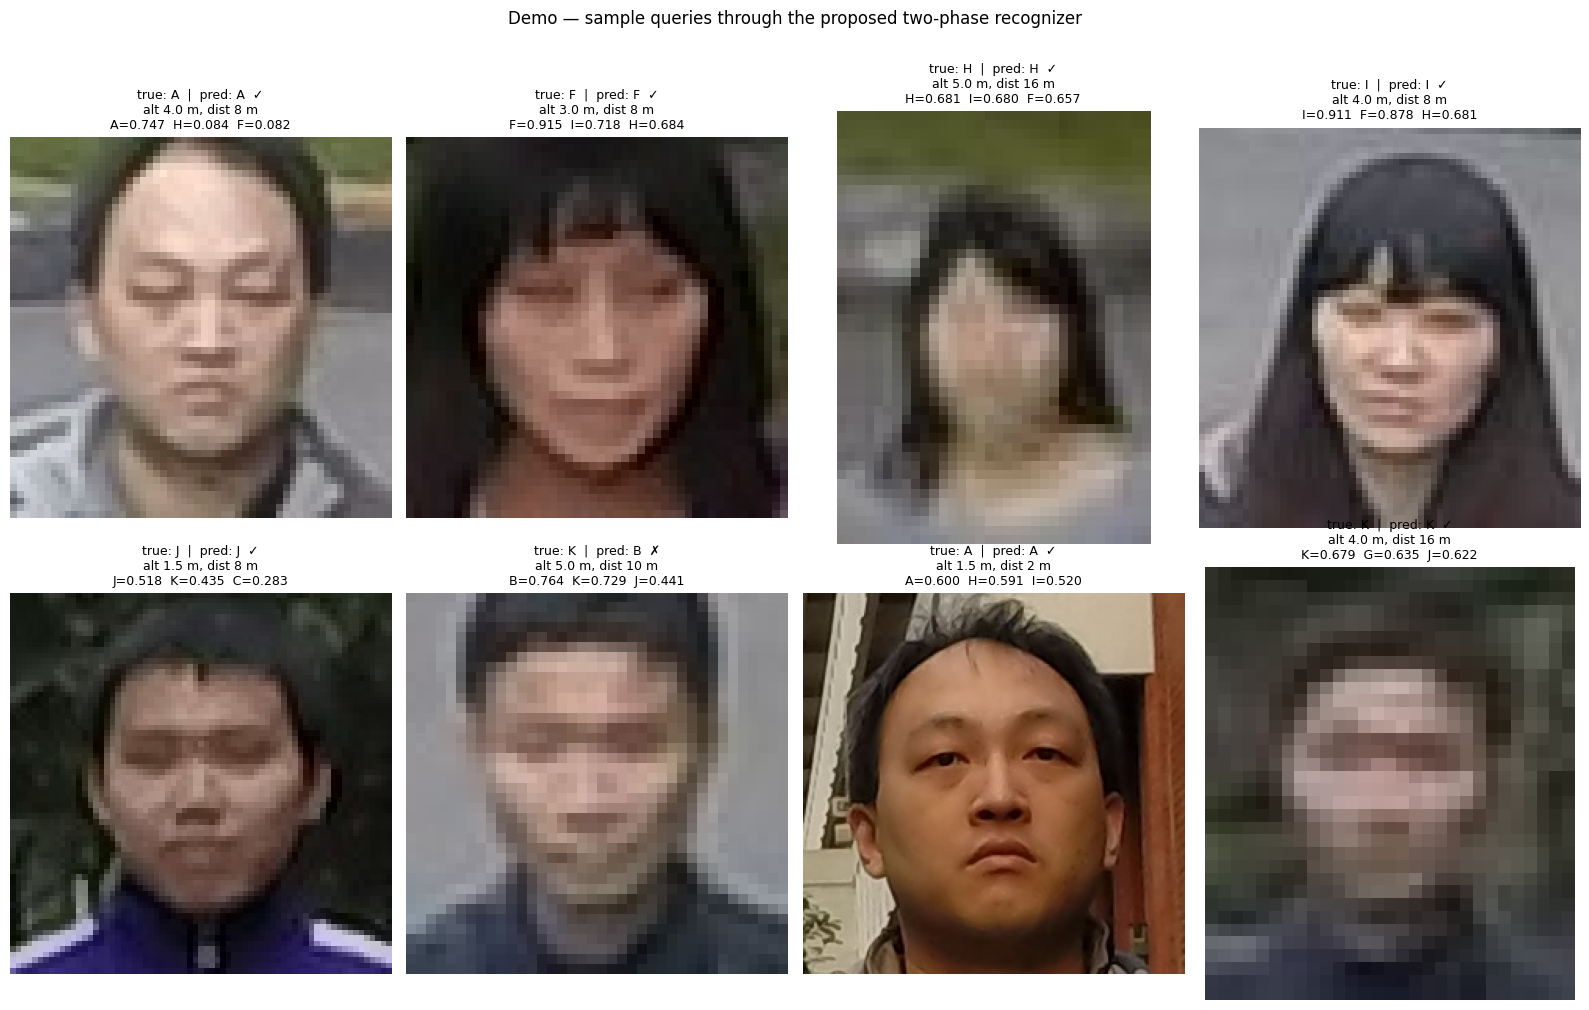


--- text summary ---

a_gp_4_ef_18.jpg  (alt=4.0m dist=8m)
  true=A  pred=A  CORRECT
  top-3: A (0.7468), H (0.0841), F (0.0820)

f_gp_3_ef_18.jpg  (alt=3.0m dist=8m)
  true=F  pred=F  CORRECT
  top-3: F (0.9146), I (0.7183), H (0.6839)

h_gp_5_ef_02.jpg  (alt=5.0m dist=16m)
  true=H  pred=H  CORRECT
  top-3: H (0.6807), I (0.6800), F (0.6566)

i_gp_4_ef_18.jpg  (alt=4.0m dist=8m)
  true=I  pred=I  CORRECT
  top-3: I (0.9110), F (0.8781), H (0.6813)

j_gp_0_ef_18.jpg  (alt=1.5m dist=8m)
  true=J  pred=J  CORRECT
  top-3: J (0.5185), K (0.4349), C (0.2826)

k_gp_5_ef_14.jpg  (alt=5.0m dist=10m)
  true=K  pred=B  INCORRECT
  top-3: B (0.7640), K (0.7287), J (0.4409)

a_gp_0_ef_30.jpg  (alt=1.5m dist=2m)
  true=A  pred=A  CORRECT
  top-3: A (0.5999), H (0.5915), I (0.5203)

k_gp_4_ef_02.jpg  (alt=4.0m dist=16m)
  true=K  pred=K  CORRECT
  top-3: K (0.6786), G (0.6345), J (0.6222)


In [5]:
n = sum(1 for idx, _ in picks if idx is not None)
ncols = 4; nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 5 * nrows))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

summary_lines = []
for ax, (idx, sample) in zip(axes, picks):
    if idx is None:
        ax.axis('off'); continue
    ident, _, _, desc = sample
    fname = Path(all_paths[idx]).name
    meta = parse_filename(fname)
    top3 = predict(idx, k=3)
    correct = top3[0][0] == ident

    img = Image.open(all_paths[idx]).convert('RGB')
    ax.imshow(img); ax.axis('off')
    title = f"true: {ident}  |  pred: {top3[0][0]}  {'✓' if correct else '✗'}\n"
    title += f"alt {meta['altitude_m']} m, dist {meta['distance_m']:.0f} m\n"
    title += '  '.join([f'{lbl}={s:.3f}' for lbl, s in top3])
    ax.set_title(title, fontsize=9)
    summary_lines.append(
        f"{fname}  (alt={meta['altitude_m']}m dist={meta['distance_m']:.0f}m)\n"
        f"  true={ident}  pred={top3[0][0]}  {'CORRECT' if correct else 'INCORRECT'}\n"
        f"  top-3: " + ', '.join([f'{lbl} ({s:.4f})' for lbl, s in top3])
    )

for ax in axes[n:]:
    ax.axis('off')
plt.suptitle('Demo — sample queries through the proposed two-phase recognizer', y=1.005, fontsize=12)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'results/demo_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n--- text summary ---\n')
print('\n\n'.join(summary_lines))
with open(PROJECT_ROOT / 'results/demo_predictions.txt', 'w') as f:
    f.write('\n\n'.join(summary_lines) + '\n')

## Outputs

- `results/demo_predictions.png` — composite figure showing the 8 query images alongside their top-3 predictions and ✓/✗ correctness flag.
- `results/demo_predictions.txt` — text summary of the same predictions, suitable for grading scripts